In [1]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import importlib
import IPython.display as ipd

import src.spatial_attn_lightning as binaural_lightning 
import yaml
from pytorch_lightning import Trainer, seed_everything

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [3]:

config_path = "config/binaural_attn/word_task_v10_cue_loc_task.yaml"
# config_path = "config/binaural_attn/word_task_half_co_loc_v06.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

config['num_workers'] = 2
config['hparas']['batch_size'] = 16
print(f"Default lr is {config['hparas']['lr']}")
# config['hparas']['lr'] = 0.000001
# print(f"Trying lr = {config['hparas']['lr']}")



Default lr is 5e-05


In [4]:
seed_everything(0)
importlib.reload(binaural_lightning)

module = binaural_lightning.BinauralAttentionModule(config)

[rank: 0] Seed set to 0


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800, 'num_locs': 792}
Model performing both location and word tasks
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


In [5]:
# kaiming_init(module, mode='fan_in', init_type='uniform')

In [6]:
# dataset = module.train_dataloader()

In [7]:
def map_azim_elev(azim,elev):
    return np.array((((elev + 40) / 10) * 72) + (azim / 5), dtype=np.int64)

elevs = np.arange(-40, 61, 10)
azims = np.arange(0, 360, 5)
loc_class_map = {(azim, elev): map_azim_elev(azim, elev) for azim in azims for elev in elevs}
print(len(loc_class_map))
print(len(elevs), len(azims))

792
11 72


In [7]:
trainer = Trainer(
    precision="32",
    limit_val_batches=0.0,
    num_nodes=1,
    # benchmark=True,
    devices=1, # was gpus=1,
    # detect_anomaly=True,
    # strategy="ddp_notebook",
    accelerator="gpu",
)
trainer.fit(module)

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /om2/user/imgriff/conda_envs/pytorch_2/lib/python3.1 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                         | Params
------------------------------------------------------------------
0 | audio_transforms | AudioCompose                 | 0     
1 | model            | BinauralAuditoryAtten

Using v06 dataset
/om/scratch/Sun/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v10
Using 0.1 cue free data
Using gender balanced training 4M set
cue type: mixed
mixture_percentages={'voice_only': 0.5, 'voice_and_location': 0.5}
1224 files in train concat dataset
len training set = 50184
Epoch 0:   0%|          | 4/50184 [00:25<88:12:49,  0.16it/s, v_num=3.96e+7, train_word_loss=6.750, train_location_loss=6.800, train_loss=13.50, grad_norm=7.650] 

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


#### Eval trained model in elevation

In [8]:
## Crude model on elevations 
from pathlib import Path 

ckpt_dir = Path('attn_cue_models')
ckpt_path = ckpt_dir / Path(config_path).stem/ "checkpoints/epoch=1-step=22546-best_loc_task.ckpt" 

model = binaural_lightning.BinauralAttentionModule.load_from_checkpoint(config = config, checkpoint_path=ckpt_path)
model = model.eval().cuda()
coch_transform = model.coch_gram.cuda()


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800, 'num_locs': 792}
Model performing both location and word tasks
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: True
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [ ]:
### Get spatialization logic
import pandas as pd
from corpus.speaker_room_dataset import SpeakerRoomDataset
import src.audio_transforms as at
from tqdm.auto import tqdm


def get_brir(azim=None, elev=None, coords=None, h5_fn=None, IR_df=None, out_sr=44_100):
    if coords is not None:
        azim, elev = coords
    df_row = IR_df[(IR_df['src_azim'] == azim) & (IR_df['src_elev'] == elev)]
    brir_ix = df_row['index_brir'].values[0]
    sr_src = df_row['sr'].values[0]
    with h5py.File(h5_fn, 'r') as f:
        brir = f['brir'][brir_ix]
    if out_sr != sr_src:
        brir = soxr.resample(brir.astype(np.float32), sr_src, out_sr)
    return brir

signal_sr = config['audio']['rep_kwargs']['sr']
coch_sr = config['audio']['rep_kwargs']['env_sr']
dataset = SpeakerRoomDataset(manifest_path='/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl',
                            excerpt_path='/om2/user/msaddler/spatial_audio_pipeline/assets/swc/manifest_all_words.pdpkl',
                            cue_type='voice_and_location',
                            sr=signal_sr) 

batch_size = 64
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

audio_transforms_0_db = at.AudioCompose([
                at.AudioToTensor(),
                at.BinauralCombineWithRandomDBSNR(low_snr=0,    # is 0 dB
                                                high_snr=0,), # is 0 dB 
                at.BinauralRMSNormalizeForegroundAndBackground(rms_level=0.02), # 20 * np.log10(0.02/20e-6) = 60 dB SPL 
        ])

audio_transforms_0_db = audio_transforms_0_db.cuda()


room_ix = 0 
test_IR_manifest_dir = Path("/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb")
test_IR_manifest_path = test_IR_manifest_dir / "manifest_brir.pdpkl"
h5_fn = test_IR_manifest_dir / f"room{room_ix:04}.hdf5"
new_room_manifest = pd.read_pickle(test_IR_manifest_path)
only14_manifest = new_room_manifest[(new_room_manifest['index_room'] == room_ix)  & (new_room_manifest['src_dist'] == 1.4)]




In [48]:
def azim_elev_to_label(azim, elev, skip_negative_elev=False):
    if skip_negative_elev:
        return np.array(((elev / 10) * 72) + (azim / 5) + 1, dtype=np.int64)
    else:
        return np.array((((elev + 40) / 10) * 72) + (azim / 5), dtype=np.int64)



def label_to_azim_elev(label):
    """
    """
    elev = np.array((label // 72) * 10) - 40
    azim = np.array((label % 72) * 5)
    return np.array(azim).astype(float), np.array(elev).astype(float)

In [17]:
import itertools

# get all locations used in training 
all_azims = np.arange(0,360,5)
all_elevs = np.arange(-40, 61, 10)

all_locs =  list(itertools.product(all_azims, all_elevs))

all_label_dict = {loc: azim_elev_to_label(*loc) for loc in all_locs}
label_to_loc_dict = {int(v): k for k, v in all_label_dict.items()}

In [19]:
len(label_to_loc_dict)

792

In [58]:
## Sweep across elevations
SAMPLERATE = signal_sr

elevs = np.arange(-20,41,10)
azim = 0 
n_to_run = 200

results_dict = {}
with torch.no_grad():
    for elev in elevs:
        results_dict[elev] = {'azim_preds': [], 'elev_preds': []}
        target_brir = get_brir(azim=azim, elev=elev, h5_fn=h5_fn, IR_df=only14_manifest, out_sr=SAMPLERATE)
        sp_to_target_loc = at.Spatialize(target_brir, model_sr=signal_sr).cuda()
        true_label = torch.tensor(azim_elev_to_label(azim, elev))
        for j, batch in enumerate(tqdm(dataloader, total= n_to_run // batch_size, leave=False)):
            if j * batch_size > n_to_run:
                break
            # just use cue here
            cue, _, _, _, _ = batch
            cue = sp_to_target_loc(cue.cuda())
            cue, _ = audio_transforms_0_db(cue, None)
            cue, _ = coch_transform(cue, None)
            _, loc_logits = model(cue, cue, None)
            loc_preds = loc_logits.softmax(-1).argmax(-1)
            # get errors per prediction 
            azim_preds, elev_preds = zip(*np.array([label_to_azim_elev(pred) for pred in loc_preds.cpu().numpy()]))            
            results_dict[elev]['azim_preds'].extend(azim_preds)
            results_dict[elev]['elev_preds'].extend(elev_preds)
      


In [59]:
results_dict.keys()

dict_keys([-20, -10, 0, 10, 20, 30, 40])

Elevation: -20, Azim Err: 0.0, Elev Err: 5.1171875
Elevation: -10, Azim Err: 5.29296875, Elev Err: 7.03125
Elevation: 0, Azim Err: 1.38671875, Elev Err: 3.2421875
Elevation: 10, Azim Err: 2.8125, Elev Err: 1.4453125
Elevation: 20, Azim Err: 4.765625, Elev Err: 1.7578125
Elevation: 30, Azim Err: 14.62890625, Elev Err: 4.4921875
Elevation: 40, Azim Err: 7.01171875, Elev Err: 4.3359375


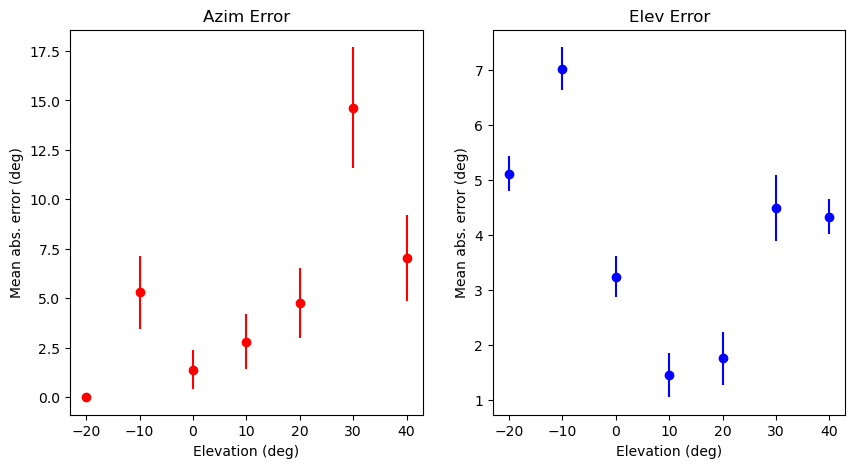

In [68]:
### Get azim preds 
fig, axs = plt.subplots(1,2, figsize=(10,5))
loc_error_dict = {}
for elev, data in results_dict.items():
    azim_preds = data['azim_preds']
    elev_preds = data['elev_preds']
    azim_err = np.abs(np.array(azim_preds) - azim)
    elev_err = np.abs(np.array(elev_preds) - elev)

    axs[0].errorbar(elev, np.mean(azim_err), yerr=np.std(azim_err)/np.sqrt(azim_err.shape[0]), fmt='o', color='r')
    axs[1].errorbar(elev, np.mean(elev_err), yerr=np.std(elev_err)/np.sqrt(elev_err.shape[0]), fmt='o', color='b')
    loc_error_dict[elev] = {'azim_err': azim_err, 'elev_err': elev_err}
    print(f"Elevation: {elev}, Azim Err: {azim_err.mean()}, Elev Err: {elev_err.mean()}")
axs[0].set_title("Azim Error")
axs[1].set_title("Elev Error")

axs[0].set_ylabel("Mean abs. error (deg)")
axs[1].set_ylabel("Mean abs. error (deg)")
for ax in axs:
    ax.set_xlabel("Elevation (deg)")


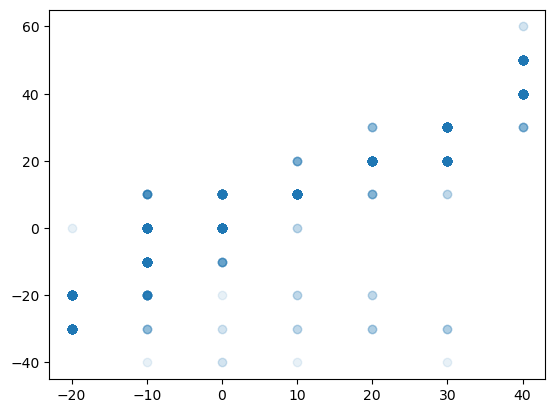

In [61]:
# Scatterplot of elevation predictions 
%matplotlib inline
import matplotlib.pyplot as plt
# import seaborn as sns

res_records = [{'true_elev': elev, 'elev_pred': elev_pred} for elev, data in results_dict.items() for azim_pred, elev_pred in zip(data['azim_preds'], data['elev_preds'])]
df_of_elev_results = pd.DataFrame(res_records)


# for elev, data in results_dict.items():
#     elev_preds = data['elev_preds']
#     plt.plot(elev, elev_preds, 'o', alpha=0.1)
plt.scatter(df_of_elev_results['true_elev'], df_of_elev_results['elev_pred'], alpha=0.1)